# 导入所需库

In [1]:
import os
import time
import re
import pickle
import pefile
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from joblib import Parallel, delayed
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction import FeatureHasher
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

mpl.rcParams['font.sans-serif'] = 'SimHei'

# 处理二进制文件特征

In [17]:
min_length = 5
string_regx = b'[\x20-\x7E]{' + str(min_length).encode() + b',}'    # 匹配从空格到~的所有字符
pattern = re.compile(string_regx)
def get_string_features(path):
    string_features = {}
    with open(path, 'rb') as f:
        strings = pattern.findall(f.read())

    for string in strings:
        string_features[string] = 1

    return string_features

def get_pe_features(pe):
    pe_features = {}
    try:
        pe_features['num_sections'] = len(pe.sections)  # 节数量
        pe_features['image_base'] = pe.OPTIONAL_HEADER.ImageBase    # 程序加载到内存中的默认地址
        pe_features['entry_point'] = pe.OPTIONAL_HEADER.AddressOfEntrypoint
    except:
        pass
    return pe_features

def get_api_features(pe):
    api_dict = {}
    try:
        for dll in pe.DIRECTORY_ENTRY_IMPORT:
            for api in dll.imports:
                if api:
                    api_dict[api.name] = 1
    except:
        pass
    return api_dict

def get_features_wrappers(path):
    try:
        pe = pefile.PE(path, fast_load=True)
        pe_features = get_pe_features(pe)
        api_features = get_api_features(pe)
        pe.close()
    except:
        pe_features = {}
        api_features = {}
    string_features = get_string_features(path)
    print('字符串长度',len(string_features))
    print('pe特征长度',len(pe_features))
    print('api特征长度',len(api_features))
    wrappers = {**pe_features, **api_features, **string_features}
    return wrappers

def get_data(benign_path, malicious_path, hasher: FeatureHasher):
    def get_path(directory):
        return [os.path.join(directory, path) for path in os.listdir(directory)]
    all_paths = get_path(benign_path) + get_path(malicious_path)

    # 使用Parallel进行并行计算
    # delayed 创建任务
    raw_features_list = Parallel(n_jobs=-1)(
        delayed(get_features_wrappers)(path) for path in all_paths
    )

    X = hasher.transform(raw_features_list)
    y = [0] * len(os.listdir(benign_path)) + [1] * len(os.listdir(malicious_path))

    return X, y

def scan(path, classifier, hasher:FeatureHasher):

    features = get_features_wrappers(path)
    features = hasher.transform([features])
    res = classifier.predict(features)
    print('恶意软件') if res else print('正常软件')

# 数据预处理

In [12]:
# hasher将特征转换为20000维度的向量
hasher = FeatureHasher(n_features=20000)    # 向量转换器
X, y = get_data('dataset/benignware', 'dataset/malware', hasher)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y, random_state=6)

In [19]:
a = get_features_wrappers('dataset/test/malware/0ed1a3bccdbabcea8c5af4a65f706056856bd46eec21b2296ffad11614872eab.exe')
print('总特征数', len(a))

字符串长度 495
pe特征长度 2
api特征长度 0
总特征数 497


# 查看正常软件与恶意软件的数量

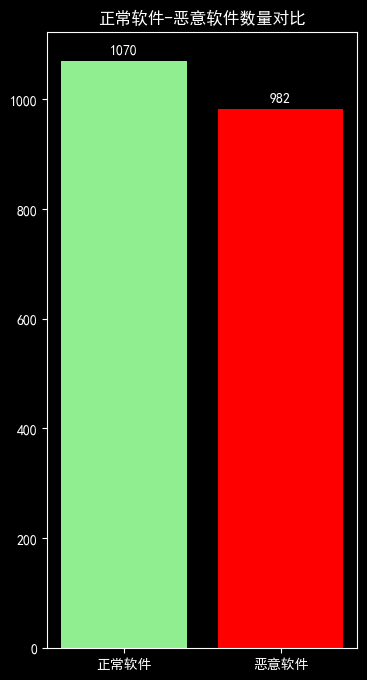

In [10]:
benignware_cnt = len(os.listdir('dataset/benignware'))
malware_cnt = len(os.listdir('dataset/malware'))
figure = plt.figure(figsize=(4, 8))
bars = plt.bar(x=['正常软件', '恶意软件'], height=[benignware_cnt, malware_cnt], color=['lightgreen', 'red'])

for bar, cnt in zip(bars, [benignware_cnt, malware_cnt]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(cnt), ha='center', va='bottom')

plt.title('正常软件-恶意软件数量对比')
plt.show()

# 随机森林

In [25]:
params = {
    'n_estimators': [100, 300, 500, 700, 900],              # 决策树数量
    'criterion': ['gini', 'entropy', 'log_loss'],           # 如何选择切分点
    'max_depth': [None, 5, 10, 15, 20],                     # 决策树的最大深度
}

forest = RandomForestClassifier(n_jobs=-1)
grid_search = GridSearchCV(
    estimator=forest,
    param_grid=params,
    cv=5,                   # 将数据集分为cv份进行交叉验证
    scoring='accuracy',     # 以准确率作为评估标准
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print('最佳参数：', grid_search.best_params_)
print('最佳分数：', grid_search.best_score_)

最佳参数： {'criterion': 'gini', 'max_depth': None, 'n_estimators': 500}
最佳分数： 0.9792812662169175


# K近邻

In [7]:
params = {
    'n_neighbors': [3, 5, 7, 9, 11, 13, 15],
    'weights': ['uniform', 'distance']
}
knn = KNeighborsClassifier(n_jobs=-1)

grid_search = GridSearchCV(
    estimator=knn,
    param_grid=params,
    cv=5,
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)
print('最佳参数：', grid_search.best_params_)
print('最佳分数：', grid_search.best_score_)

最佳参数： {'n_neighbors': 7, 'weights': 'distance'}
最佳分数： 0.94881940840685


# 逻辑回归

In [8]:
params = {
    'penalty': ['l1', 'l2'], # 正则化系数(给错分的添加惩罚)，防止过拟合
    'solver': ['liblinear', 'lbfgs'],   # 指定优化算法
    'C': [0.1, 1, 10, 100]
}

logistic = LogisticRegression(n_jobs=-1)
grid_search = GridSearchCV(
    estimator=logistic,
    param_grid=params,
    cv=5,
    n_jobs=-1
)
grid_search.fit(X_train, y_train)
print('最佳参数：', grid_search.best_params_)
print('最佳分数：', grid_search.best_score_)

D:\Document\Project\MalwareDataScience\.venv\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
20 fits failed out of a total of 80.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
20 fits failed with the following error:
Traceback (most recent call last):
  File "D:\Document\Project\MalwareDataScience\.venv\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "D:\Document\Project\MalwareDataScience\.venv\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "D:\Document\Project\MalwareDataScience\.venv\Lib\si

最佳参数： {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
最佳分数： 0.9670954110756913


# 测试各模型的误报率与漏报率

In [49]:
malware_cnt = y_test.count(1)
benignware_cnt = len(y_test) - malware_cnt
print(f'测试集中正常软件数量: {benignware_cnt}, 恶意软件数量: {malware_cnt}')
# 随机森林
forest_neglect = 0   # 漏报
forest_worse = 0     # 误报
# 最佳参数  'criterion': 'gini', 'max_depth': None, 'n_estimators': 500
forest = RandomForestClassifier(criterion='gini', max_depth=None, n_estimators=500)
forest.fit(X_train, y_train)
start = time.time()
for x, y in zip(X_test, y_test):
    pred = forest.predict(x)
    if pred == 0 != y: # 漏报
        forest_neglect += 1
    elif pred == 1 != y: # 误报
        forest_worse += 1
end = time.time()
forest_score = f"{forest.score(X_test, y_test)*100:.2f}"
forest_time = int(end - start)
forest_neglect_rate = forest_neglect / malware_cnt
forest_worse_rate = forest_worse / benignware_cnt
print(f'漏报率：{forest_neglect_rate:.2%}, 误报率: {forest_worse_rate:.2%}, 耗时: {forest_time}s, 得分: {forest_score}')

测试集中正常软件数量: 214, 恶意软件数量: 197
漏报率：2.54%, 误报率: 2.34%, 耗时: 10s, 得分: 97.57


In [50]:
# K近邻
# 最佳参数： {'n_neighbors': 7, 'weights': 'distance'}
knn_neglect = 0
knn_worse = 0
knn = KNeighborsClassifier(n_neighbors=7, weights='distance')
knn.fit(X_train, y_train)
start = time.time()
for x, y in zip(X_test, y_test):
    pred = knn.predict(x)
    if pred == 0 != y:  # 漏报
        knn_neglect += 1
    elif pred == 1 != y:    # 误报
        knn_worse += 1
end = time.time()
knn_score = f"{knn.score(X_test, y_test)*100:.2f}"
knn_time = int(end - start)
knn_neglect_rate = knn_neglect / malware_cnt
knn_worse_rate = knn_worse / benignware_cnt
print(f'漏报率：{knn_neglect_rate:.2%}, 误报率: {knn_worse_rate:.2%}, 耗时: {knn_time}s, 得分: {knn_score}')

漏报率：2.03%, 误报率: 9.35%, 耗时: 15s, 得分: 94.16


In [51]:
# 逻辑回归
# 最佳参数： {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'}
logistic_neglect = 0
logistic_worse = 0
logistic = LogisticRegression(random_state=4, C=100, penalty='l1', solver='liblinear')
logistic.fit(X_train, y_train)
start = time.time()
for x, y in zip(X_test, y_test):
    pred = logistic.predict(x)
    if pred == 0 != y:  # 漏报
        logistic_neglect += 1
    elif pred == 1 != y:    # 误报
        logistic_worse += 1
end = time.time()
logistic_score = f"{logistic.score(X_test, y_test)*100:.2f}"
logistic_time = round(end - start, 2)
logistic_neglect_rate = logistic_neglect / malware_cnt
logistic_worse_rate = logistic_worse / benignware_cnt
print(f'漏报率：{logistic_neglect_rate:.2%}, 误报率: {logistic_worse_rate:.2%}, 耗时: {logistic_time}s, 得分: {logistic_score}')

D:\Document\Project\MalwareDataScience\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
D:\Document\Project\MalwareDataScience\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


漏报率：5.08%, 误报率: 2.34%, 耗时: 0.03s, 得分: 96.35


# 模型性能对比

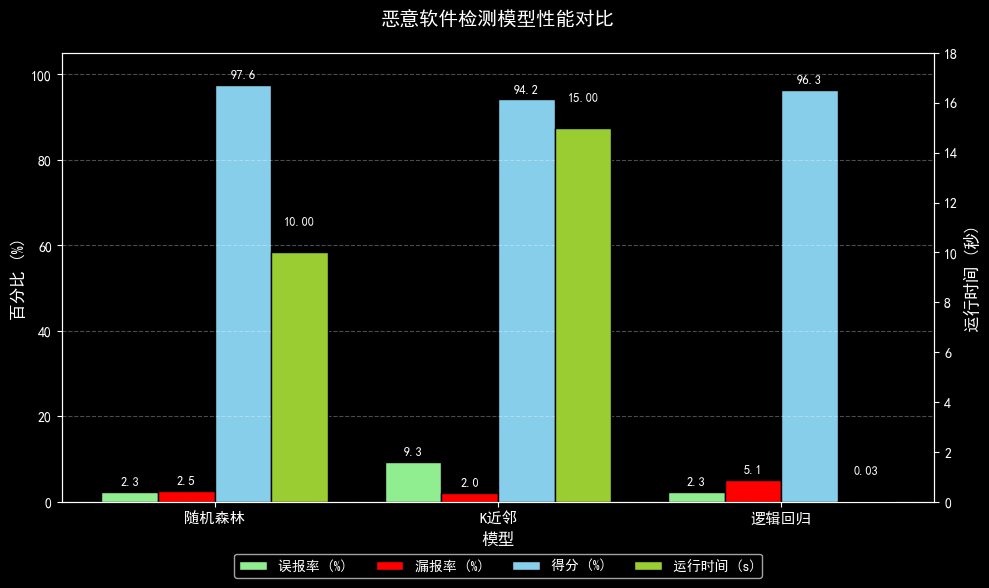

In [54]:
# 设置中文字体
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 模型名称
models = ['随机森林', 'K近邻', '逻辑回归']

# 误报率（%）
false_positive_rates = [2.34, 9.35, 2.34]

# 漏报率（%）
false_negative_rates = [2.54, 2.03, 5.08]

# 得分（%）
scores = [97.57, 94.16, 96.35]

# 运行时间（秒）
run_times = [10, 15, 0.03]

# 设置柱状图的位置
x = np.arange(len(models))  # 模型位置
width = 0.2  # 柱状图宽度

# 创建图形和坐标轴
fig, ax1 = plt.subplots(figsize=(10, 6))

# 绘制误报率柱状图
bars1 = ax1.bar(x - 1.5*width, false_positive_rates, width,
                label='误报率 (%)', color='lightgreen', edgecolor='black')

# 绘制漏报率柱状图
bars2 = ax1.bar(x - 0.5*width, false_negative_rates, width,
                label='漏报率 (%)', color='red', edgecolor='black')

# 绘制得分柱状图
bars3 = ax1.bar(x + 0.5*width, scores, width,
                label='得分 (%)', color='skyblue', edgecolor='black')

# 创建第二个y轴用于显示运行时间
ax2 = ax1.twinx()

# 绘制运行时间柱状图（使用不同的y轴刻度）
bars4 = ax2.bar(x + 1.5*width, run_times, width,
                label='运行时间 (s)', color='yellowgreen', edgecolor='black')

# 设置x轴标签
ax1.set_xlabel('模型', fontsize=12, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(models, fontsize=11)

# 设置左侧y轴标签（误报率、漏报率、得分）
ax1.set_ylabel('百分比 (%)', fontsize=12, fontweight='bold')
ax1.set_ylim(0, 105)  # 设置y轴范围

# 设置右侧y轴标签（运行时间）
ax2.set_ylabel('运行时间 (秒)', fontsize=12, fontweight='bold')
ax2.set_ylim(0, max(run_times) * 1.2)  # 设置y轴范围

# 添加标题
plt.title('恶意软件检测模型性能对比', fontsize=14, fontweight='bold', pad=20)

# 添加数据标签
def add_labels(bars, ax, is_time=False):
    for bar in bars:
        height = bar.get_height()
        # 如果是时间数据，保留2位小数
        if is_time:
            label = f'{height:.2f}'
        else:
            label = f'{height:.1f}'

        ax.text(bar.get_x() + bar.get_width()/2, height + 1,
                label, ha='center', va='bottom', fontsize=9)

add_labels(bars1, ax1)
add_labels(bars2, ax1)
add_labels(bars3, ax1)
add_labels(bars4, ax2, is_time=True)

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper center', bbox_to_anchor=(0.5, -0.1),
           ncol=4, fontsize=10)

# 添加网格线
ax1.grid(axis='y', alpha=0.3, linestyle='--')

# 调整布局
plt.tight_layout()

# 显示图形
plt.show()

# 检测真实程序

In [58]:
scan(r"C:\Users\yue\Desktop\test.exe", forest, hasher)                  # 后门
scan(r'dataset/benignware/WeChatWin_4.1.6.exe', forest, hasher)         # 微信安装包
scan(r'dataset/benignware/WeChat.exe', forest, hasher)                  # 微信主程序
scan(r"D:\Develop\PycharmPro\PyCharm 2025.1.2\bin\pycharm64.exe", forest, hasher) # pycharm主程序

恶意软件
正常软件
正常软件
正常软件


# 保存模型

In [59]:
with open('./model.pkl', 'wb') as f:
    pickle.dump((forest, hasher), f)